In [137]:
# https://en.wikipedia.org/wiki/Convolutional_neural_network

This Project will be build today:

* Classify whether a picture of food contains pizza 🍕 or steak 🥩 (we're going to do this).
* Detect whether or not an object appears in an image (e.g. did a specific car pass through a security camera?)


### What I will Cover in this notebook:

* Getting a dataset to work with
* Architecture of a convolutional neural network
* A quick end-to-end example (what we're working towards)
* Steps in modelling for binary image classification with CNNs
    * Becoming one with the data
    * Preparing data for modelling
    * Creating a CNN model (starting with a baseline)
    * Fitting a model (getting it to find patterns in our data)
    * Evaluating a model
    * Improving a model
    * Making a prediction with a trained model
* Steps in modelling for multi-class image classification with CNNs
* Same as above (but this time with a different dataset)

In [81]:
import datetime
print(f"Notebook last tun (end-to-end): {datetime.datetime.now()}")

Notebook last tun (end-to-end): 2025-02-13 12:59:18.561259


## Get the data

The images we're going to work with are from the [Food-101 dataset](https://data.vision.ee.ethz.ch/cvl/datasets_extra/food-101/), a collection of 101 different categories of 101,000 (1000 images per category) real-world images of food dishes.

To begin, we're only going to use two of the categories, pizza 🍕 and steak 🥩 and build a binary classifier.

In [82]:
!pip install kagglehub

In [83]:
!mkdir -p ~/.kaggle
!mv kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

mv: cannot stat 'kaggle.json': No such file or directory


In [84]:
import kagglehub
import shutil

In [ ]:
# # Define your target folder
# target_folder = "/content/food_dataset"

# # Download the dataset
# path = kagglehub.dataset_download("kmader/food41")

# # Move the dataset to the target folder
# shutil.move(path, target_folder)

# print("Dataset saved in:", target_folder)

In [85]:
# This also works: !kaggle datasets download -d kmader/food41 -p /content/food_dataset --unzip

import zipfile

# Download zip file of pizza_steak images
!wget https://storage.googleapis.com/ztm_tf_course/food_vision/pizza_steak.zip

# Unzip the downloaded file
zip_ref = zipfile.ZipFile("pizza_steak.zip", "r")
zip_ref.extractall()
zip_ref.close()

--2025-02-13 12:59:28--  https://storage.googleapis.com/ztm_tf_course/food_vision/pizza_steak.zip
Resolving storage.googleapis.com (storage.googleapis.com)... 172.253.63.207, 142.250.31.207, 142.251.111.207, ...
Connecting to storage.googleapis.com (storage.googleapis.com)|172.253.63.207|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 109540975 (104M) [application/zip]
Saving to: ‘pizza_steak.zip.1’

pizza_steak.zip.1   100%[===================>] 104.47M  90.2MB/s    in 1.2s    

2025-02-13 12:59:30 (90.2 MB/s) - ‘pizza_steak.zip.1’ saved [109540975/109540975]



### Inspect the data (become one with it)

* A `train` directory which contains all of the images in the training dataset with subdirectories each named after a certain class containing images of that class.


* A `test` directory with the same structure as the train directory.

In [86]:
!ls pizza_steak

test  train


In [87]:
!ls pizza_steak/train/

pizza  steak


In [88]:
!ls pizza_steak/train/steak/

1000205.jpg  1598345.jpg  2062248.jpg  2548974.jpg  3030578.jpg  3571963.jpg  510757.jpg
100135.jpg   1598885.jpg  2081995.jpg  2549316.jpg  3047807.jpg  3576078.jpg  513129.jpg
101312.jpg   1600179.jpg  2087958.jpg  2561199.jpg  3059843.jpg  3577618.jpg  513842.jpg
1021458.jpg  1600794.jpg  2088030.jpg  2563233.jpg  3074367.jpg  3577732.jpg  523535.jpg
1032846.jpg  160552.jpg   2088195.jpg  256592.jpg   3082120.jpg  3578934.jpg  525041.jpg
10380.jpg    1606596.jpg  2090493.jpg  2568848.jpg  3094354.jpg  358042.jpg   534560.jpg
1049459.jpg  1615395.jpg  2090504.jpg  2573392.jpg  3095301.jpg  358045.jpg   534633.jpg
1053665.jpg  1618011.jpg  2125877.jpg  2592401.jpg  3099645.jpg  3591821.jpg  536535.jpg
1068516.jpg  1619357.jpg  2129685.jpg  2599817.jpg  3100476.jpg  359330.jpg   541410.jpg
1068975.jpg  1621763.jpg  2133717.jpg  2603058.jpg  3110387.jpg  3601483.jpg  543691.jpg
1081258.jpg  1623325.jpg  2136662.jpg  2606444.jpg  3113772.jpg  3606642.jpg  560503.jpg
1090122.jpg  1624450.

Woah, a whole bunch of images.

In [89]:
import os

# Listing number of files.
for dirpath, dirnames, filenames in os.walk("pizza_steak"):
    print(f"There are {len(dirnames)} directories and {len(filenames)} images in {dirpath}.")

There are 2 directories and 0 images in pizza_steak.
There are 2 directories and 0 images in pizza_steak/test.
There are 0 directories and 250 images in pizza_steak/test/steak.
There are 0 directories and 250 images in pizza_steak/test/pizza.
There are 2 directories and 0 images in pizza_steak/train.
There are 0 directories and 750 images in pizza_steak/train/steak.
There are 0 directories and 750 images in pizza_steak/train/pizza.


In [90]:
# Another way to find out how many images are in a file.
num_steak_images_train = len(os.listdir("pizza_steak/train/steak"))
num_steak_images_train

750

In [91]:
# Fetching the class names programmatically, this is much more helpful with a longer list of classes.
import pathlib
import numpy as np

data_dir = pathlib.Path("pizza_steak/train/") # turn our training path into a Python path.
class_names = np.array(sorted([item.name for item in data_dir.glob("*")])) # created a list of class_names from the subdirectories.

print(class_names)

['pizza' 'steak']


Okay, so we've got a collection of 750 training images and 250 testing images of pizza and steak.

> `🤔 Note:-` Whenever you're working with data, it's always good to visualize it as much as possible. Treat your first couple of steps of a project as becoming one with the data. `Visualize`, `visualize`, `visualize`.

Image shape: (384, 512, 3)


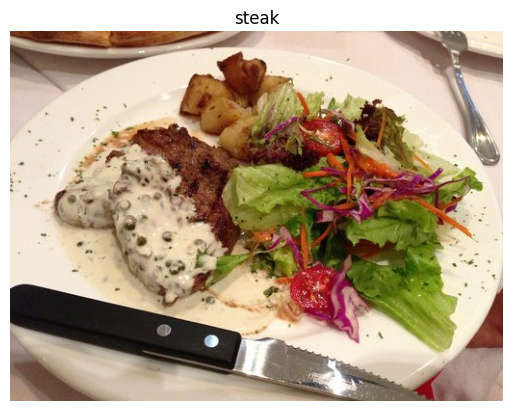

In [92]:
# View an image.
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import random

# Creating an function to visualize the images.
def view_random_image(target_dir, target_class):
    # Setup target directory (we'll view images from here..)
    target_folder = target_dir + target_class

    # Get a random image path.
    random_image = random.sample(os.listdir(target_folder), 1)

    # Read in the image and plot it using matplotlib.
    img = mpimg.imread(target_folder + "/" + random_image[0])
    plt.imshow(img)
    plt.title(target_class)
    plt.axis("off");

    print(f"Image shape: {img.shape}") # show the shape of the image.

    return img

# View a random image from the training dataset.
img = view_random_image(
    target_dir = "pizza_steak/train/",
    target_class="steak"
)


After going through a dozen or so images from the different classes, we can start to get an idea of what we're working with.

The entire Food101 dataset comprises of similar images from 101 different classes.

We might've noticed we've been printing the image shape alongside the plotted image.

This is because the way our computer sees the image is in the form of a big array (tensor).

array([[[118,  60,  38],
        [117,  59,  35],
        [121,  61,  37],
        ...,
        [252, 232, 207],
        [253, 233, 208],
        [254, 234, 209]],

       [[110,  53,  33],
        [110,  54,  31],
        [113,  55,  31],
        ...,
        [253, 233, 208],
        [253, 233, 208],
        [253, 233, 208]],

       [[104,  52,  31],
        [106,  54,  33],
        [111,  59,  37],
        ...,
        [251, 234, 208],
        [252, 232, 207],
        [252, 232, 207]],

       ...,

       [[180, 145, 126],
        [176, 143, 124],
        [175, 142, 123],
        ...,
        [192, 160, 139],
        [193, 161, 140],
        [196, 164, 143]],

       [[179, 142, 124],
        [178, 143, 124],
        [179, 144, 125],
        ...,
        [195, 160, 140],
        [196, 161, 141],
        [198, 163, 143]],

       [[181, 144, 126],
        [182, 145, 127],
        [181, 146, 127],
        ...,
        [198, 163, 143],
        [200, 163, 144],
        [202, 165, 146]]], dtype=uint8)
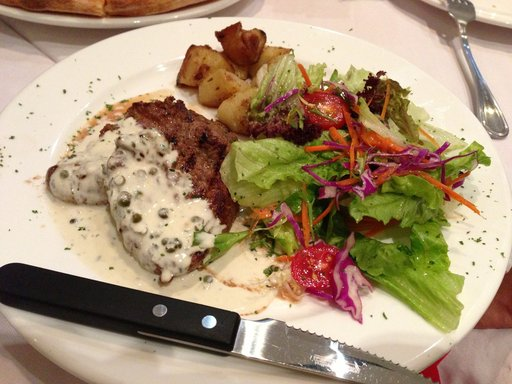

In [93]:
# View the img (actually just a big array/tensor)
img

Image shape: `(Width, Height, Colour Channels)`.

In our case, the width and height vary but because we're dealing with colour images, the colour channels value is always 3. This is for different values of red, green and blue (RGB) pixels.

We might have noticed all of the values in the img array are between `0` and `255`. This is because that's the possible range for red, green and blue values.

For example, a pixel with a value `red=0`, `green=0`, `blue=255` will look very blue.

> `🔑 Note:-` As we've discussed before, many machine learning models, including neural networks prefer the values they work with to be between 0 and 1. Knowing this, one of the most common preprocessing steps for working with images is to scale (also referred to as `normalize`) their pixel values by dividing the image arrays by `255`.

In [94]:
# Get all the pixel values between 0 & 1.
img/255

array([[[0.4627451 , 0.23529412, 0.14901961],
        [0.45882353, 0.23137255, 0.1372549 ],
        [0.4745098 , 0.23921569, 0.14509804],
        ...,
        [0.98823529, 0.90980392, 0.81176471],
        [0.99215686, 0.91372549, 0.81568627],
        [0.99607843, 0.91764706, 0.81960784]],

       [[0.43137255, 0.20784314, 0.12941176],
        [0.43137255, 0.21176471, 0.12156863],
        [0.44313725, 0.21568627, 0.12156863],
        ...,
        [0.99215686, 0.91372549, 0.81568627],
        [0.99215686, 0.91372549, 0.81568627],
        [0.99215686, 0.91372549, 0.81568627]],

       [[0.40784314, 0.20392157, 0.12156863],
        [0.41568627, 0.21176471, 0.12941176],
        [0.43529412, 0.23137255, 0.14509804],
        ...,
        [0.98431373, 0.91764706, 0.81568627],
        [0.98823529, 0.90980392, 0.81176471],
        [0.98823529, 0.90980392, 0.81176471]],

       ...,

       [[0.70588235, 0.56862745, 0.49411765],
        [0.69019608, 0.56078431, 0.48627451],
        [0.68627451, 0

### A (typical) architecture of a convolutional neural network:


Components of a convolutional neural network:

Hyperparameter/Layer type:

* `Input image(s):` Target images you'd like to discover patterns in --> Whatever you can take a photo (or video) of.

* `Input layer:`	Takes in target images and preprocesses them for further layers	--> `input_shape = [batch_size, image_height, image_width, color_channels]`

* `Convolution layer`:	Extracts/learns the most important features from target images --> Multiple, can create with `tf.keras.layers.ConvXD` (X can be multiple values)

* `Hidden activation`:	Adds non-linearity to learned features (non-straight lines)	--> Usually ReLU (`tf.keras.activations.relu`)

* `Pooling layer`:	Reduces the dimensionality of learned image features --> 	`Average` (`tf.keras.layers.AvgPool2D`) or `Max` (`tf.keras.layers.MaxPool2D`).

* `Fully connected layer`:	Further refines learned features from convolution layers --> `tf.keras.layers.Dense`

* `Output layer`: Takes learned features and outputs them in shape of target labels	--> `output_shape = [number_of_classes]` (e.g. 3 for pizza, steak or sushi).

* `Output activation`:	Adds non-linearities to output layer --> `tf.keras.activations.sigmoid` (`binary classification`) or `tf.keras.activations.softmax`

> `🔑 Note:-` A baseline is a score or evaluation metric we want to try and beat. Usually we'll start with a simple model, create a baseline and try to beat it by increasing the complexity of the model.

`📖 Resource:` The architecture we're using below is a scaled-down version of VGG-16, a convolutional neural network which came 2nd in the 2014 ImageNet classification competition.



In [95]:
!pip install keras

In [96]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Set the seed
tf.random.set_seed(42)

# Preprocess data (get all of the pixel values between 1 and 0, also called scaling/normalization)
train_datagen = ImageDataGenerator(rescale=1./255)
valid_datagen = ImageDataGenerator(rescale=1./255)

# Setup the train and test directories
train_dir = "/content/pizza_steak/train"
test_dir = "/content/pizza_steak/test"


print("Train directory exists:", os.path.exists("pizza_steak/train/"))
print("Test directory exists:", os.path.exists("pizza_steak/test/"))

print("Train files:", os.listdir("pizza_steak/train/") if os.path.exists("pizza_steak/train/") else "Not found")
print("Test files:", os.listdir("pizza_steak/test/") if os.path.exists("pizza_steak/test/") else "Not found")


# Import data from directories and turn it into batches
train_data = train_datagen.flow_from_directory(train_dir,
                                               batch_size=32, # number of images to process at a time
                                               target_size=(224, 224), # convert all images to be 224 x 224
                                               class_mode="binary", # type of problem we're working on
                                               seed=42)

valid_data = valid_datagen.flow_from_directory(test_dir,
                                               batch_size=32,
                                               target_size=(224, 224),
                                               class_mode="binary",
                                               seed=42)
# Create CNN model (same as Tiny-VGG).
model_1 = tf.keras.models.Sequential([
  tf.keras.layers.Conv2D(filters=10,
                         kernel_size=3, # can also be (3, 3)
                         activation="relu",
                         input_shape=(224, 224, 3)), # first layer specifies input shape (height, width, colour channels)
  tf.keras.layers.Conv2D(10, 3, activation="relu"),
  tf.keras.layers.MaxPool2D(pool_size=2, # pool_size can also be (2, 2)
                            padding="valid"), # padding can also be 'same'
  tf.keras.layers.Conv2D(10, 3, activation="relu"),
  tf.keras.layers.Conv2D(10, 3, activation="relu"), # activation='relu' == tf.keras.layers.Activations(tf.nn.relu)
  tf.keras.layers.MaxPool2D(2),
  tf.keras.layers.Flatten(),
  tf.keras.layers.Dense(1, activation="sigmoid") # binary activation output
])

# Compile the model
model_1.compile(loss="binary_crossentropy",
              optimizer=tf.keras.optimizers.Adam(),
              metrics=["accuracy"])

Train directory exists: True
Test directory exists: True
Train files: ['steak', 'pizza']
Test files: ['steak', 'pizza']
Found 1500 images belonging to 2 classes.
Found 500 images belonging to 2 classes.


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [97]:
# Fit the model
history_1 = model_1.fit(train_data,
                        epochs=5,
                        steps_per_epoch=len(train_data),
                        validation_data=valid_data,
                        validation_steps=len(valid_data))

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 115s 2s/step - accuracy: 0.5778 - loss: 0.6839 - val_accuracy: 0.8020 - val_loss: 0.4501
Epoch 2/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 109s 2s/step - accuracy: 0.7700 - loss: 0.4690 - val_accuracy: 0.8420 - val_loss: 0.3726
Epoch 3/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 138s 2s/step - accuracy: 0.8242 - loss: 0.4275 - val_accuracy: 0.8220 - val_loss: 0.3899
Epoch 4/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 109s 2s/step - accuracy: 0.8065 - loss: 0.4183 - val_accuracy: 0.8380 - val_loss: 0.3562
Epoch 5/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 106s 2s/step - accuracy: 0.8653 - loss: 0.3431 - val_accuracy: 0.8460 - val_loss: 0.3640


> 🤔 Note: If the cell above takes more than ~12 seconds per epoch to run, then it might be the we are not enabling the GPU accelerator. If we're using a Colab notebook, we can access a GPU accelerator by going to Runtime -> Change Runtime Type -> Hardware Accelerator and select "GPU". After doing so, we might have to rerun all of the above cells as changing the runtime type causes Colab to have to reset.

Nice! After 5 epochs, our model beat the baseline score of 50.76% accuracy (our model got ~85% accuaracy on the training set and ~85% accuracy on the test set).

However, our model only went through a binary classificaiton problem rather than all of the 101 classes in the Food101 dataset, so we can't directly compare these metrics. That being said, the results so far show that our model is learning something.

In [98]:
# Check out the layers in our model
model_1.summary()

Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_29 (Conv2D)                   │ (None, 222, 222, 10)        │             280 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_30 (Conv2D)                   │ (None, 220, 220, 10)        │             910 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_13 (MaxPooling2D)      │ (None, 110, 110, 10)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_31 (Conv2D)                   │ (None, 108, 108, 10)        │             910 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_32 (Conv2D)                   │ (None, 106, 106, 10)        │             910 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_14 (MaxPooling2D)      │ (None, 53, 53, 10)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_10 (Flatten)                 │ (None, 28090)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_15 (Dense)                     │ (None, 1)                   │          28,091 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 93,305 (364.48 KB)

 Trainable params: 31,101 (121.49 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 62,204 (242.99 KB)

* The `ImageDataGenerator` class and the `rescale` parameter.

* The `flow_from_directory()` method.

    * The `batch_size` parameter

    * The `target_size` parameter

* `Conv2D` layers (and the parameters which come with them).

* `MaxPool2D` layers (and their parameters).

* The `steps_per_epoch` and `validation_steps` parameters in the `fit()` function.

We can use all of the same parameters in our previous model except for changing two things:

* The data - we're now working with images instead of dots.
* The input shape - we have to tell our neural network the shape of the images we're working with.
    * A common practice is to reshape images all to one size. In our case, we'll resize the images to (224, 224, 3), meaning a height and width of 224 pixels and a depth of 3 for the red, green, blue colour channels.

In [99]:
# set random seed.
tf.random.set_seed(42)

# Create a model to replicate the TensorFlow Playground model
model_2 = tf.keras.Sequential([
  tf.keras.layers.Flatten(input_shape=(224, 224, 3)), # dense layers expect a 1-dimensional vector as input.
  tf.keras.layers.Dense(4, activation='relu'),
  tf.keras.layers.Dense(4, activation='relu'),
  tf.keras.layers.Dense(1, activation='sigmoid')
])

# Compile the model
model_2.compile(loss='binary_crossentropy',
              optimizer=tf.keras.optimizers.Adam(),
              metrics=["accuracy"])

# Fit the model
history_2 = model_2.fit(train_data, # use same training data created above
                        epochs=5,
                        steps_per_epoch=len(train_data),
                        validation_data=valid_data, # use same validation data created above
                        validation_steps=len(valid_data))

/usr/local/lib/python3.11/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 9s 170ms/step - accuracy: 0.4929 - loss: 2.2090 - val_accuracy: 0.5000 - val_loss: 0.6932
Epoch 2/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 10s 159ms/step - accuracy: 0.4940 - loss: 0.6932 - val_accuracy: 0.5000 - val_loss: 0.6932
Epoch 3/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 10s 163ms/step - accuracy: 0.5164 - loss: 0.6930 - val_accuracy: 0.5000 - val_loss: 0.6932
Epoch 4/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 8s 164ms/step - accuracy: 0.5122 - loss: 0.6931 - val_accuracy: 0.5000 - val_loss: 0.6932
Epoch 5/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 10s 159ms/step - accuracy: 0.5025 - loss: 0.6932 - val_accuracy: 0.5000 - val_loss: 0.6932


In [100]:
# Check out our second model's architecture
model_2.summary()

Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ flatten_11 (Flatten)                 │ (None, 150528)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_16 (Dense)                     │ (None, 4)                   │         602,116 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_17 (Dense)                     │ (None, 4)                   │              20 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_18 (Dense)                     │ (None, 1)                   │               5 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,806,425 (6.89 MB)

 Trainable params: 602,141 (2.30 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,204,284 (4.59 MB)

One of the most noticeable things here is the much larger number of parameters in `model_2` versus `model_1`.

`model_2` has `602,141` trainable parameters where as `model_1` has only `31,101`. And despite this difference, `model_1` still far and large out performs `model_2`.

🔑 `Note:-` We can think of trainable parameters as patterns a model can learn from data. Intuitiely, we might think more is better. And in some cases it is. But in this case, the difference here is in the two different styles of model we're using. Where a series of dense layers have a number of different learnable parameters connected to each other and hence a higher number of possible learnable patterns, a convolutional neural network seeks to sort out and learn the most important patterns in an image. So, even though there are less learnable parameters in our convolutional neural network, these are often more helpful in decphering between different features in an image.

Since our previous model didn't work, Have any ideas of how we might make it work ?

How about we increase the number of layers?

And maybe even increase the number of neurons in each layer?

More specifically, we'll increase the `number of neurons` (also called `hidden units`) in each dense layer from `4` to `100` and add an `extra layer`.

> 🔑 `Note:-` Adding `extra layers` or `increasing the number of neurons` in each layer is often referred to as increasing the complexity of your model.


In [101]:
# Set random seed
tf.random.set_seed(42)

# Create a model similar to model_1 but add an extra layer and increase the number of hidden units in each layer
model_3 = tf.keras.Sequential([
  tf.keras.layers.Flatten(input_shape=(224, 224, 3)), # dense layers expect a 1-dimensional vector as input
  tf.keras.layers.Dense(100, activation='relu'), # increase number of neurons from 4 to 100 (for each layer)
  tf.keras.layers.Dense(100, activation='relu'),
  tf.keras.layers.Dense(100, activation='relu'), # add an extra layer
  tf.keras.layers.Dense(1, activation='sigmoid')
])

# Compile the model
model_3.compile(loss='binary_crossentropy',
              optimizer=tf.keras.optimizers.Adam(),
              metrics=["accuracy"])

# Fit the model
history_3 = model_3.fit(train_data,
                        epochs=5,
                        steps_per_epoch=len(train_data),
                        validation_data=valid_data,
                        validation_steps=len(valid_data))

Epoch 1/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 24s 454ms/step - accuracy: 0.5826 - loss: 8.1957 - val_accuracy: 0.7140 - val_loss: 0.9061
Epoch 2/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 22s 463ms/step - accuracy: 0.7133 - loss: 0.8470 - val_accuracy: 0.7560 - val_loss: 0.5051
Epoch 3/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 41s 453ms/step - accuracy: 0.7668 - loss: 0.5348 - val_accuracy: 0.6720 - val_loss: 0.6223
Epoch 4/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 21s 441ms/step - accuracy: 0.7137 - loss: 0.6653 - val_accuracy: 0.7400 - val_loss: 0.5166
Epoch 5/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 41s 449ms/step - accuracy: 0.7432 - loss: 0.5078 - val_accuracy: 0.7720 - val_loss: 0.4827


 Looks like our model is learning again. It got `~78%` accuracy on the training set and `60%` accuracy on the validation set.

In [102]:
# Check out model_3 architecture.
model_3.summary()

Model: "sequential_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ flatten_12 (Flatten)                 │ (None, 150528)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_19 (Dense)                     │ (None, 100)                 │      15,052,900 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_20 (Dense)                     │ (None, 100)                 │          10,100 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_21 (Dense)                     │ (None, 100)                 │          10,100 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_22 (Dense)                     │ (None, 1)                   │             101 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 45,219,605 (172.50 MB)

 Trainable params: 15,073,201 (57.50 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 30,146,404 (115.00 MB)

The number of trainable parameters has increased even more than `model_2`. And even with close to `500x` (`~15,000,000` vs. `~31,000`) more trainable parameters, `model_3` still doesn't out perform `model_1`.

## Binary classification: Let's break it down:

1. Become one with the data (visualize, visualize, visualize...)
2. Preprocess the data (prepare it for a model)
3. Create a model (start with a baseline)
4. Fit the model
5. Evaluate the model
6. Adjust different parameters and improve model (try to beat your baseline)
7. Repeat until satisfied

### 1. Import and become one with the data

In [ ]:
# import zipfile

# # Download zip file of pizza_steak images
# !wget https://storage.googleapis.com/ztm_tf_course/food_vision/pizza_steak.zip

# # Unzip the downloaded file
# zip_ref = zipfile.ZipFile("pizza_steak.zip", "r")
# zip_ref.extractall()
# zip_ref.close()

Image shape: (512, 512, 3)
Image shape: (512, 512, 3)


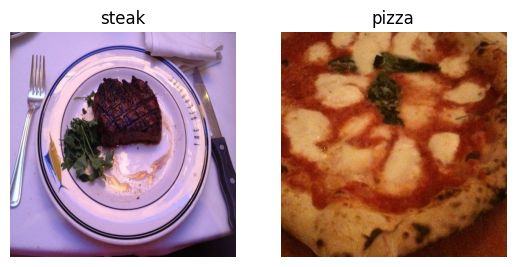

In [103]:
# Visualize data (requires function "view_random_images" above)
plt.figure()
plt.subplot(1, 2, 1)
steak_img = view_random_image("pizza_steak/train/", "steak")
plt.subplot(1, 2, 2)
pizza_img = view_random_image("pizza_steak/train/", "pizza")

### 2. Preprocess the data (prepare it for a model)

In [104]:
# Define training and test directory paths.
train_dir = "pizza_steak/train/"
test_dir = "pizza_steak/test/"

---

Our next step is to turn our data into `batches`.

A `batch` is a small subset of the dataset a model looks at during training. For example, rather than looking at `10,000 images` at one time and trying to figure out the patterns, a `model` might only look at `32 images` at a time.

Creating an `batches` is necessary because of the following reasons:

* `10,000` images (or more) might not fit into the memory or processor (GPU).

* Trying to learn the patterns in `10,000 images` in `one hit` could result in the model not being able to learn very well.

---

Why 32 ?  --> `batch size` of 32 is good for your health.There are many different `batch sizes` we could use but 32 has proven to be very effective in many different use cases and is often the default for many data preprocessing functions.


To turn our data into `batches`, we'll first create an instance of `ImageDataGenerator` for each of our datasets.

In [105]:
# Create train and test data generators and rescale the data.
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Rescaling of the data into the 0 to 1. forms.
train_datagen = ImageDataGenerator(rescale=1/255.)
test_datagen = ImageDataGenerator(rescale=1/255.)

Reasons of Implementing the ImageDataGenerator Class:

* It helps us to prepare our images into batches as well as performs some kinds of transformations on them as they get loaded into the model.

* `rescale` parameter along with 1/255. ---> Implementation of Transformation is like "divide all of the pixels values by 255". This results in all of the images being imported and their pixesl values being normalized (converted to be between 0 and 1).

> 🔑 `Note:-` For more transformation options such as `data augmentation` (we'll see this later), refer to the [ImageDataGenerator](https://www.tensorflow.org/api_docs/python/tf/keras/preprocessing/image/ImageDataGenerator) documentation.

Now, we've got a couple of `ImageDataGenerator` instances, we can load our images from their respective directories using the `flow_from_directory` method.

In [106]:
# Turn it into batches.

# since our data is in the forms of directory structure so that we are using flow_from_directory But if there were dataframe we would have been using the flow_from_dataframe.
'''
flow_from_directory(
    directory,
    target_size=(256, 256),
    color_mode='rgb',
    classes=None,
    class_mode='categorical',
    batch_size=32,
    shuffle=True,
    seed=None,
    save_to_dir=None,
    save_prefix='',
    save_format='png',
    follow_links=False,
    subset=None,
    interpolation='nearest',
    keep_aspect_ratio=False
)
'''
train_data = train_datagen.flow_from_directory(directory=train_dir,
                                  target_size=(224, 224), # Converting images into the 224, 224 size.
                                  class_mode="binary", # since we are performing the binary classification so that we are using the `binary` here.
                                  batch_size=32)

test_data = test_datagen.flow_from_directory(directory=test_dir,
                                 target_size=(224, 224),
                                 class_mode="binary",
                                 batch_size=32)

Found 1500 images belonging to 2 classes.
Found 500 images belonging to 2 classes.


Looks like our training dataset has 1500 images belonging to 2 classes (pizza and steak) and our test dataset has 500 images also belonging to 2 classes.

Important things to notice here:

* Due to how our directories are structured, the classes get inferred by the subdirectory names in `train_dir` and `test_dir`.

* The `target_size` parameter defines the input size of our images in (`height`, `width`) format.

* The `class_mode` value of `'binary'` defines our classification problem type. If we had more than two classes, we would use `'categorical'`.

* The `batch_size` defines how many images will be in each batch, we've used `32` which is the same as the default.

In [107]:
# Let's looks at our batched images and labels by inspecting the train_data object.

# Get a sample of the training data batch.
images, labels = next(train_data) # In previous version of keras, train_data.next() -- .next() method was used to fetch the next batch.
len(images), len(labels)

(32, 32)

It seems our images and labels are in batches of 32.

In [108]:
# Get the first two images.
images[:2], images[0].shape

(array([[[[0.56078434, 0.63529414, 0.79215693],
          [0.5647059 , 0.6392157 , 0.7960785 ],
          [0.5647059 , 0.6392157 , 0.80392164],
          ...,
          [0.07843138, 0.08235294, 0.05882353],
          [0.08235294, 0.08235294, 0.07450981],
          [0.09803922, 0.09803922, 0.09803922]],
 
         [[0.5647059 , 0.6392157 , 0.7960785 ],
          [0.5568628 , 0.6313726 , 0.7960785 ],
          [0.5568628 , 0.6313726 , 0.7960785 ],
          ...,
          [0.09803922, 0.10196079, 0.07058824],
          [0.0627451 , 0.06666667, 0.04705883],
          [0.04313726, 0.04313726, 0.03529412]],
 
         [[0.5686275 , 0.6431373 , 0.8078432 ],
          [0.5647059 , 0.6392157 , 0.80392164],
          [0.5647059 , 0.6392157 , 0.8078432 ],
          ...,
          [0.07450981, 0.07843138, 0.04705883],
          [0.15686275, 0.16078432, 0.13725491],
          [0.21568629, 0.21960786, 0.20000002]],
 
         ...,
 
         [[0.3921569 , 0.34901962, 0.22352943],
          [0.39607

Since, We have implemented the `re-scale` paramter in the `ImageDataGenerator`, that's why images are now in `(224, 224, 3)` shape tensors with values between `0` & `1`.

In [109]:
# View the first batch of labels.
labels

array([0., 1., 1., 0., 1., 0., 1., 1., 0., 1., 0., 0., 1., 1., 1., 0., 0.,
       0., 0., 1., 1., 1., 0., 0., 0., 0., 1., 1., 0., 1., 0., 1.],
      dtype=float32)

Due to the `class_mode` parameter being `'binary'` our labels are either `0` (`pizza`) or `1` (`steak`).

### 3. Create a model (start with a baseline)

A simple heuristic for computer vision models is to use the model architecture which is performing best on `ImageNet` (a large collection of diverse images to benchmark different computer vision models).

However, to begin with, it's good to build a smaller model to acquire a baseline result which you try to improve upon.

> 🔑 `Note:-` In deep learning a smaller model often refers to a model with less layers than the state of the art (SOTA). For example, a smaller model might have 3-4 layers where as a state of the art model, such as, ResNet50 might have 50+ layers.

In [110]:
# Make the creating of our model a little easier.
from tensorflow.keras.layers import Conv2D, Dense, Flatten, MaxPool2D, Activation
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import Sequential

# Building an Sequential Layers. (thisc an be our baseline, a 3 layer Convolutional Neural Network).
model_4 = Sequential([
    Conv2D(
        filters=10,
        kernel_size=3,
        strides=1,
        padding="valid",
        activation="relu",
        input_shape=(224, 224, 3)), # shape of the input layer.

    Conv2D(10, 3, activation="relu"),
    Conv2D(10, 3, activation="relu"),
    Flatten(),
    Dense(1, activation="sigmoid") # Output layer (specify output shape)
])

`Structure Follows:-` Input --> Conv + ReLU layers (non-linearities) --> Pooling Layer --> Fully Connected (dense layer) as Output.

Explanation of some of the Components of the `Conv2D` Layer:

* The `2D` means our inputs are two dimensional (height and width), even though they have 3 colour channel, the convolutions are run on each channel individual.

* `filters`: these are the number of "feature extractors" that will be moving over our images.

* `kernel_size`: the size of our filters, for example, a `kernel_size` of `(3, 3)` (or just 3) will mean each filter will have the size 3x3, meaning it will look at a space of 3x3 pixels each time. The smaller the kernel, the more fine-grained features it will extract.

* `stride`: the number of pixels a `filter` will move accross as it covers the image. A `stride` of 1 means the filter moves across each pixels 1 by 1. A `stride` of 2 means it moves 2 pixels at a time.

* `padding`: this can be either `same` or `valid`, `same` add zeros the to outside of the image so resulting output of the convolutional layers is the same as the input, where as `valid` (default) cuts off excess pixels where the `filter` does not fit 224 pixels wide divided by a kernel size of 3 (224/3 = 74.6) means a single pixel will get cut off the end.

What's a `"feature"`?

A `feature` can be considered any significant part of an image. For example, in our case, a feature might be the circular shape of pizza. Or the rough edges on the outside of a steak.

It's important to note that these features are not defined by us, instead, the model learns them as it applies different filters across the image.



In [111]:
# Compile the model
model_4.compile(loss='binary_crossentropy',
                optimizer=Adam(),
                metrics=['accuracy'])
# Adam with all the default settings is our optimizer and our evaluation metric is accuracy.

Since we're working on a binary classification problem (pizza vs. steak), the `loss` function we're using is `'binary_crossentropy'`, if it was mult-iclass, we might use something like `'categorical_crossentropy'`.


### 4. Fit a model.

* `steps_per_epoch`: This is the number of `batches` a model will go through per epoch, in our case, we want our model to go through all batches so it's equal to the length of `train_data` (`1500 images` in batches of 32 = 1500/32 = ~47 steps).

* `validation_steps` - Same as above, except for the `validation_data` parameter (500 test images in batches of 32 = 500/32 = ~16 steps)

In [112]:
# Check lengths of training and test data generators.
len(train_data), len(test_data)

(47, 16)

In [113]:
# Fit the model.
history_4 = model_4.fit(
    train_data,
    epochs=5,
    steps_per_epoch=len(train_data),
    validation_data=test_data,
    validation_steps=len(test_data)
)

Epoch 1/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 128s 3s/step - accuracy: 0.5513 - loss: 5.9511 - val_accuracy: 0.7400 - val_loss: 0.5943
Epoch 2/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 125s 3s/step - accuracy: 0.7682 - loss: 0.5179 - val_accuracy: 0.8420 - val_loss: 0.3729
Epoch 3/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 124s 3s/step - accuracy: 0.8196 - loss: 0.4190 - val_accuracy: 0.8380 - val_loss: 0.3938
Epoch 4/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 124s 3s/step - accuracy: 0.8558 - loss: 0.3274 - val_accuracy: 0.8240 - val_loss: 0.3906
Epoch 5/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 121s 3s/step - accuracy: 0.9362 - loss: 0.2037 - val_accuracy: 0.8320 - val_loss: 0.3515


## 5. Evaluate the model.

 Looks like our model is learning something.

<Axes: >

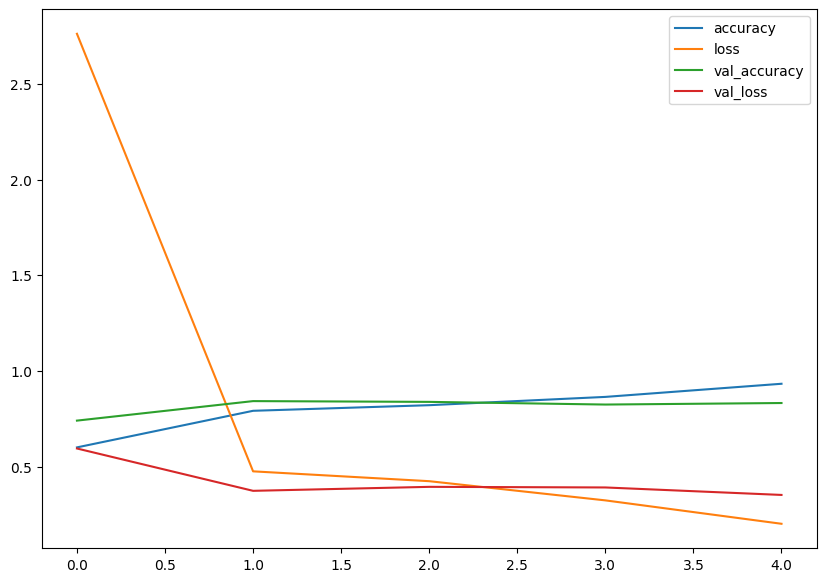

In [114]:
# Plot the training curves.
import pandas as pd
pd.DataFrame(history_4.history).plot(figsize=(10, 7))

It looks like our model is overfitting the training dataset.

> 🔑 **`Note:-`** When a model's validation loss starts to increase, it's likely that it's overfitting the training dataset. This means, it's learning the patterns in the training dataset too well and thus its ability to generalize to unseen data will be diminished.



To further inspect our model's training performance, let's separate the accuracy and loss curves.

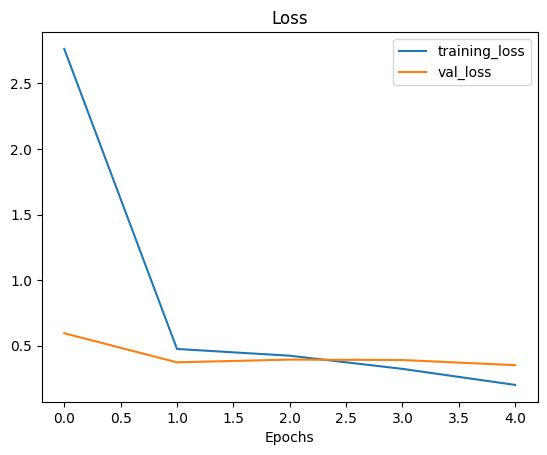

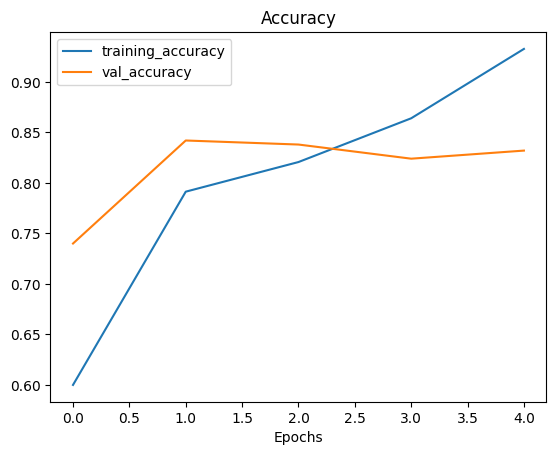

In [115]:
# Plot the validation and training data separately.
def plot_loss_curves(history):
    """
        Returns separate loss curves for training and validation metrics.
    """
    loss = history.history["loss"]
    val_loss = history.history["val_loss"]

    accuracy = history.history["accuracy"]
    val_accuracy = history.history["val_accuracy"]

    epochs = range(len(history.history["loss"]))

    # Plot loss.
    plt.plot(epochs, loss, label="training_loss")
    plt.plot(epochs, val_loss, label="val_loss")
    plt.title("Loss")
    plt.xlabel("Epochs")
    plt.legend()

    # Plot accuracy.
    plt.figure()
    plt.plot(epochs, accuracy, label="training_accuracy")
    plt.plot(epochs, val_accuracy, label="val_accuracy")
    plt.title("Accuracy")
    plt.xlabel("Epochs")
    plt.legend()

# Check out the loss curves of model_4.
plot_loss_curves(history_4)


The ideal position for these two curves is to follow each other. If anything, the validation curve should be slightly under the training curve. If there's a large gap between the training curve and validation curve, it means your model is probably overfitting.

In [116]:
# Check out our model's architecture
model_4.summary()

Model: "sequential_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_33 (Conv2D)                   │ (None, 222, 222, 10)        │             280 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_34 (Conv2D)                   │ (None, 220, 220, 10)        │             910 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_35 (Conv2D)                   │ (None, 218, 218, 10)        │             910 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_13 (Flatten)                 │ (None, 475240)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_23 (Dense)                     │ (None, 1)                   │         475,241 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,432,025 (5.46 MB)

 Trainable params: 477,341 (1.82 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 954,684 (3.64 MB)


### 6. Adjust the model parameters.

Fitting a machine learning model comes in 3 steps:

0. Create a basline.

1. Beat the baseline by overfitting a larger model.

2. Reduce overfitting.

So, far we've gone through steps `0` and `1`.

And there are even a few more things we could try to further overfit our model:

* Increase the number of convolutional layers.
* Increase the number of convolutional filters.
* Add another dense layer to the output of our flattened layer.

But what we'll do instead is focus on getting our model's training curves to better align with eachother, in other words, we'll take on step 2.

Q. Why is reducing overfitting important?
* When a model performs too well on training data and poorly on unseen data, it's not much use to us if we wanted to use it in the real world.

Say we were building a pizza vs. steak food classifier app, and our model performs very well on our training data but when users tried it out, they didn't get very good results on their own food images, is that a good experience?

Not really...

So, for the next few models we build, we're going to adjust a number of parameters and inspect the training curves along the way.

Namely, we'll build 2 more models:

* A ConvNet with max pooling.
* A ConvNet with max pooling and data augmentation.

For the first model, we'll follow the modified basic CNN structure

`Input -> Conv layers + ReLU layers (non-linearities) + Max Pooling layers -> Fully connected (dense layer) as Output.`

It'll have the same structure as `model_4` but with a `MaxPool2D()` layer after each convolutional layer.


In [117]:
# Create the model (this can be our baseline, a 3 layer Convolutional Neural Network).
model_5 = Sequential([
    Conv2D(10, 3, activation="relu", input_shape=(224, 224, 3)),
    MaxPool2D(pool_size=2), # reduce number of features by half.
    Conv2D(10, 3, activation="relu"),
    MaxPool2D(),
    Conv2D(10, 3, activation="relu"),
    MaxPool2D(),
    Flatten(),
    Dense(1, activation="sigmoid")
])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


We've got another layer type we haven't seen before.

If convolutional layers learn the features of an image then we can think of a Max Pooling layer as figuring out the most important of those features. We'll see this an example of this in a moment.

In [118]:
# Compile model (same as model_4)
model_5.compile(loss="binary_crossentropy",
                optimizer=Adam(),
                metrics=["accuracy"])

In [119]:
# Fit the model.
history_5 = model_5.fit(train_data,
                        epochs=5,
                        steps_per_epoch=len(train_data),
                        validation_data=test_data,
                        validation_steps=len(test_data))

Epoch 1/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 55s 1s/step - accuracy: 0.6118 - loss: 0.6486 - val_accuracy: 0.7300 - val_loss: 0.4981
Epoch 2/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 57s 1s/step - accuracy: 0.7883 - loss: 0.4591 - val_accuracy: 0.8500 - val_loss: 0.3624
Epoch 3/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 78s 1s/step - accuracy: 0.8205 - loss: 0.4240 - val_accuracy: 0.8540 - val_loss: 0.3398
Epoch 4/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 52s 1s/step - accuracy: 0.8416 - loss: 0.3822 - val_accuracy: 0.8660 - val_loss: 0.3190
Epoch 5/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 82s 1s/step - accuracy: 0.8486 - loss: 0.3556 - val_accuracy: 0.8700 - val_loss: 0.3353


It looks like our model with `max pooling` (model_5) is performing worse on the training set but better on the validation set.

Let's check out its architecture.

In [123]:
# Summary of the model.
model_5.summary()

Model: "sequential_14"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_36 (Conv2D)                   │ (None, 222, 222, 10)        │             280 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_15 (MaxPooling2D)      │ (None, 111, 111, 10)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_37 (Conv2D)                   │ (None, 109, 109, 10)        │             910 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_16 (MaxPooling2D)      │ (None, 54, 54, 10)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_38 (Conv2D)                   │ (None, 52, 52, 10)          │             910 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_17 (MaxPooling2D)      │ (None, 26, 26, 10)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_14 (Flatten)                 │ (None, 6760)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_24 (Dense)                     │ (None, 1)                   │           6,761 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 26,585 (103.85 KB)

 Trainable params: 8,861 (34.61 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 17,724 (69.24 KB)

We can notice what's going on here with the output shape in each `MaxPooling2D` layer?
* It gets halved each time. This is effectively the `MaxPooling2D layer` taking the outputs of each `Conv2D layer` and saying "I only want the most important features, get rid of the rest".

* The bigger the `pool_size` parameter, the more the `max pooling layer` will `squeeze` the features out of the image. However, too big and the model might not be able to learn anything.

The results of this pooling are seen in a major reduction of total `trainable parameters` (`8,861` in `model_5` and `477,431` in `model_4`).

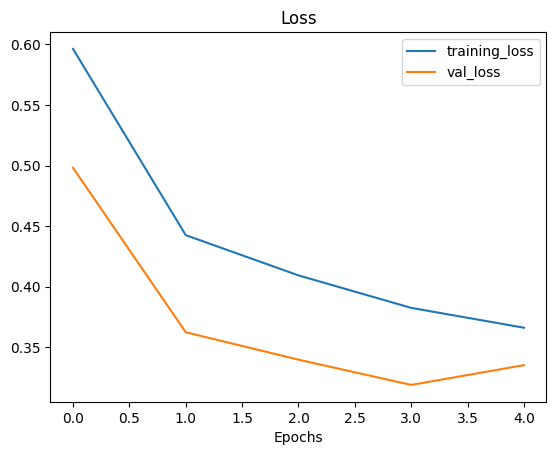

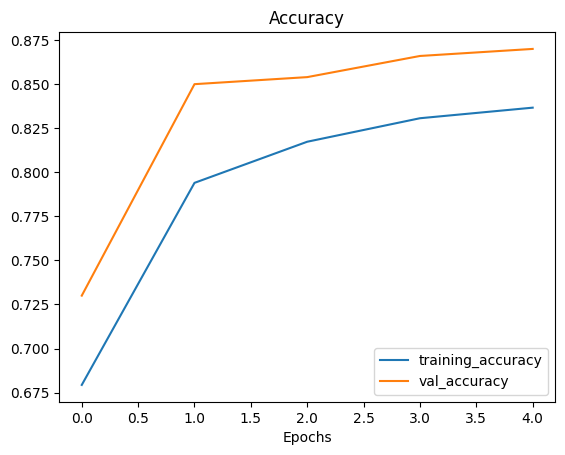

In [122]:
# Plot loss curves of model_5 results
plot_loss_curves(history_5)

Nice! We can see the training curves get a lot closer to eachother. However, our the validation loss looks to start increasing towards the end and in turn potentially leading to overfitting.

Time to dig into our bag of tricks and try another method of overfitting prevention, `data augmentation`.

First, we'll see how it's done with code then we'll discuss what it's doing.

`Note:-` Data Augmentation can be used to prevent the overfitting.

In [126]:
# create ImageDataGenerator training instance with data augmentation.
train_datagen_augmented = ImageDataGenerator(
    rescale=1/255.,
    rotation_range=20, # rotate the image slightly ) & 20 degree. (note: this is an int not a float)
    shear_range=0.2, # shear the image.
    zoom_range = 0.2, # zoom into the image.
    width_shift_range = 0.2, # shift the image with width ways.
    height_shift_range = 0.2, # shift the image heighht ways.
    horizontal_flip=True # flip the image on the horizontal axis.
)

# Create ImageDataGenerator training instance without data augmentation.
train_data = ImageDataGenerator(rescale=1/255.)

# Create ImageDataGenerator test instance without data augmentation.
test_datagen = ImageDataGenerator(rescale=1/255.)

> 🤔 Question: What's data augmentation ?

> * Data Augmentation is the process of altering our training data, leading to it having more diversity and in turn allowing our models to learn more generalizable patterns. Altering might mean adjusting the rotation of an image, flipping it, cropping it, or something similar.  Doing this simulates the kind of data a model might be used on in the real world.

If we're building a pizza vs. steak application, not all of the images our users take might be in similar setups to our training data. Using data augmentation gives us another way to prevent overfitting and in turn make our model more generalizable.

> 🔑 `Note:-` `Data augmentation` is usally only performed on the `training data`. Using the `ImageDataGenerator` built-in `data augmentation parameters` our images are left as they are in the directories but are randomly manipulated when loaded into the model.

In [127]:
# Import data and augment it from training directory.
print("Augmented Training Images: ")
train_data_augmented = train_datagen_augmented.flow_from_directory(
    train_dir,
    target_size=(224, 224),
    class_mode="binary",
    shuffle=False # Don't shuffle for demonstration purposes, usually a good thing to shuffle
)

# Create non-augmented data batches.
print("Non-augmented training images: ")
train_data = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224, 224),
    class_mode="binary",
    shuffle=False # Don't shuffle for demonstration purposes
)

print("Unchanged test images..")
test_data = test_datagen.flow_from_directory(
    test_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode="binary"
)

Augmented Training Images: 
Found 1500 images belonging to 2 classes.
Non-augmented training images: 
Found 1500 images belonging to 2 classes.
Unchanged test images..
Found 500 images belonging to 2 classes.


In [128]:
# Get next batch samples.
images, label = next(train_data)
augmented_images, augmented_labels = next(train_data_augmented)

23


(-0.5, 223.5, 223.5, -0.5)

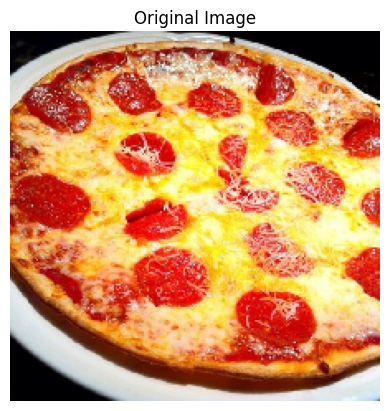

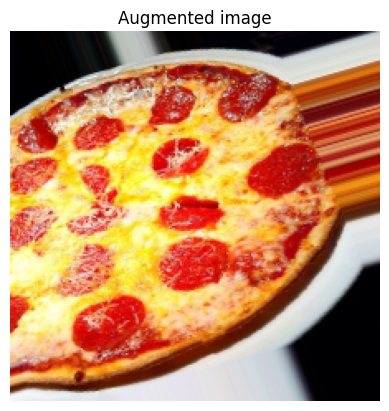

In [131]:
# Show Original image and augmented image.
random_number = random.randint(0, 31) # we are making batches of size 32, so we will get a random instance.
print(random_number)
plt.imshow(images[random_number])
plt.title(f"Original Image")
plt.axis(False)
plt.figure()

plt.imshow(augmented_images[random_number])
plt.title(f"Augmented image")
plt.axis(False)

After going through a sample of original and augmented images, we can start to see some of the example transformations on the training images.

Notice how some of the augmented images look like slightly warped versions of the original image. This means our model will be forced to try and learn patterns in less-than-perfect images, which is often the case when using real-world images.

> 🤔 `Question:` Should I use data augmentation? And how much should I augment ?

`Data augmentation` is a way to try and `prevent a model overfitting`. If your model is overfiting (e.g. the `validation loss` keeps `increasing`), you may want to try using `data augmentation`.

As for how much to data augment, there's no set practice for this. Best to check out the options in the `ImageDataGenerator class` and think about how a model in our use case might benefit from some data augmentation.

Now we've got augmented data, let's try and refit a model on it and see how it affects training.


In [132]:
# Create the model (same as model_5)
model_6 = Sequential([
  Conv2D(10, 3, activation='relu', input_shape=(224, 224, 3)),
  MaxPool2D(pool_size=2), # reduce number of features by half
  Conv2D(10, 3, activation='relu'),
  MaxPool2D(),
  Conv2D(10, 3, activation='relu'),
  MaxPool2D(),
  Flatten(),
  Dense(1, activation='sigmoid')
])

# Compile the model
model_6.compile(loss='binary_crossentropy',
                optimizer=Adam(),
                metrics=['accuracy'])

# Fit the model
history_6 = model_6.fit(train_data_augmented, # changed to augmented training data
                        epochs=5,
                        steps_per_epoch=len(train_data_augmented),
                        validation_data=test_data,
                        validation_steps=len(test_data))

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 78s 2s/step - accuracy: 0.6971 - loss: 0.7001 - val_accuracy: 0.5160 - val_loss: 0.6919
Epoch 2/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 68s 1s/step - accuracy: 0.5354 - loss: 0.6924 - val_accuracy: 0.5180 - val_loss: 0.6825
Epoch 3/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 68s 1s/step - accuracy: 0.4867 - loss: 0.6920 - val_accuracy: 0.5180 - val_loss: 0.6737
Epoch 4/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 71s 2s/step - accuracy: 0.5754 - loss: 0.7059 - val_accuracy: 0.5620 - val_loss: 0.6839
Epoch 5/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 68s 1s/step - accuracy: 0.5610 - loss: 0.6861 - val_accuracy: 0.7840 - val_loss: 0.6208


> 🤔 `Question:-` Why didn't our model get very good results on the training set to begin with ?

* It's because when we created train_data_augmented we turned off data shuffling using shuffle=False which means our model only sees a batch of a single kind of images at a time.

* For example, the pizza class gets loaded in first because it's the first class. Thus it's performance is measured on only a single class rather than both classes. The validation data performance improves steadily because it contains shuffled data.

* Since, we only set shuffle=False for demonstration purposes (so we could plot the same augmented and non-augmented image), we can fix this by setting shuffle=True on future data generators.

* We may have also noticed each epoch taking longer when training with augmented data compared to when training with non-augmented data (~25s per epoch vs. ~10s per epoch) ---> This is because the ImageDataGenerator instance augments the data as it's loaded into the model. The benefit of this is that it leaves the original images unchanged. The downside is that it takes longer to load them in.

> 🔑 `Note:-` One possible method to speed up dataset manipulation would be to look into TensorFlow's `parrallel reads` and `buffered prefecting options`.

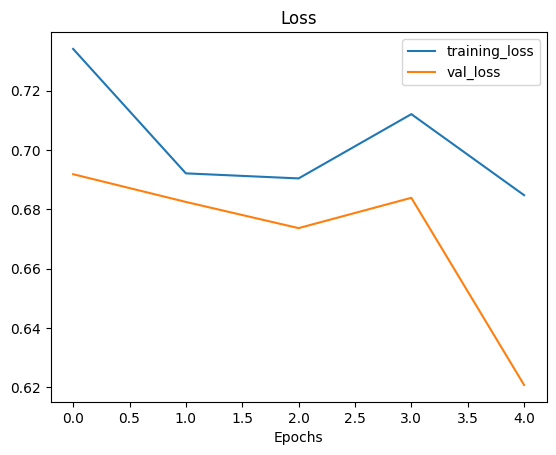

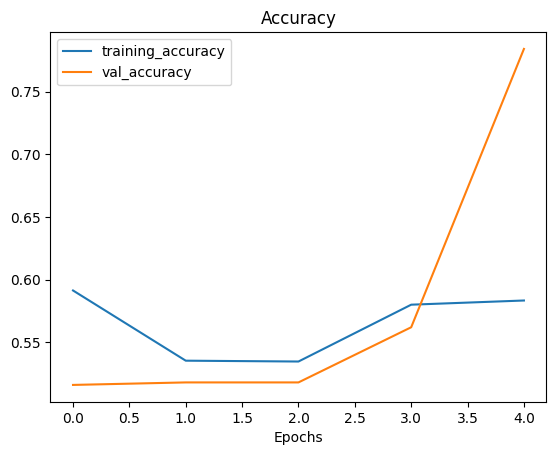

In [133]:
# Check model's performance history training on augmented data
plot_loss_curves(history_6)


It seems our validation loss curve is heading in the right direction but it's a bit jumpy (the most ideal loss curve isn't too spiky but a smooth descent, however, a perfectly smooth loss curve is the equivalent of a fairytale).

Let's see what happens when we shuffle the augmented training data.

In [134]:
# Import data and augment it from directories.
train_data_augmented_shuffled = train_datagen_augmented.flow_from_directory(
    train_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode="binary",
    shuffle=True # Data shuffling.
)

Found 1500 images belonging to 2 classes.


In [ ]:
# Create the model.(same as model_5 and model_6)
model_7 = Sequential([
    Conv2D(10, 3, activation='relu', input_shape=(224, 224, 3)),
    MaxPool2D(),
    Conv2D(10, 3, activation='relu'),
    MaxPool2D(),
    Conv2D(10, 3, activation='relu'),
    MaxPool2D(),
    Flatten(),
    Dense(1, activation='sigmoid')
])

# Compile the model
model_7.compile(loss='binary_crossentropy',
                optimizer=Adam(),
                metrics=['accuracy'])

# Fit the model
history_7 = model_7.fit(train_data_augmented_shuffled, # now the augmented data is shuffled
                        epochs=5,
                        steps_per_epoch=len(train_data_augmented_shuffled),
                        validation_data=test_data,
                        validation_steps=len(test_data))

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 72s 1s/step - accuracy: 0.5586 - loss: 0.6757 - val_accuracy: 0.7340 - val_loss: 0.4982
Epoch 2/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 80s 1s/step - accuracy: 0.7650 - loss: 0.5076 - val_accuracy: 0.8380 - val_loss: 0.3884
Epoch 3/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 86s 2s/step - accuracy: 0.7880 - loss: 0.4717 - val_accuracy: 0.8260 - val_loss: 0.3897
Epoch 4/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 78s 1s/step - accuracy: 0.7830 - loss: 0.4891 - val_accuracy: 0.8740 - val_loss: 0.3114
Epoch 5/5
36/47 ━━━━━━━━━━━━━━━━━━━━ 14s 1s/step - accuracy: 0.8121 - loss: 0.4272

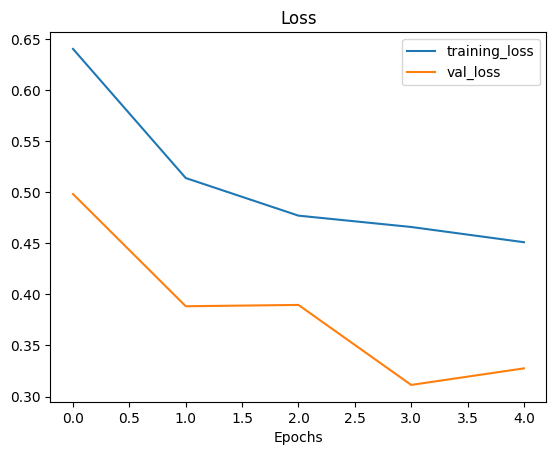

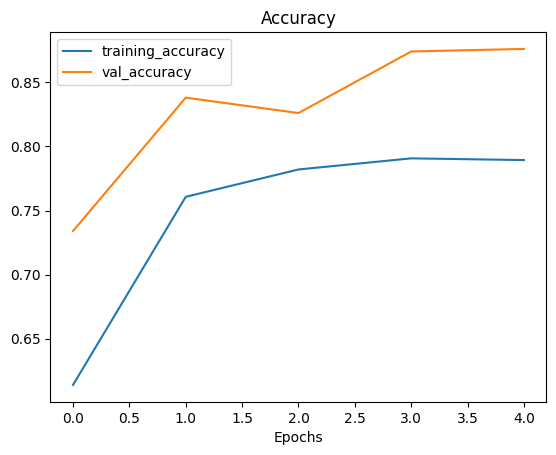

In [138]:
# Check model's performance history training on augmented data
plot_loss_curves(history_7)

Notice with `model_7` how the performance on the training dataset improves almost immediately compared to `model_6`. This is because we shuffled the training data as we passed it to the model using the parameter shuffle=True in the flow_from_directory method.

This means the model was able to see examples of both pizza and steak images in each batch and in turn be evaluated on what it learned from both images rather than just one kind.

Also, our loss curves look a little bit smoother with shuffled data (comparing `history_6` to `history_7`).

### Repeat until satisified:

We've trained a few model's on our dataset already and so far they're performing pretty good.

Since we've already beaten our baseline, there are a few things we could try to continue to improve our model:

* Increase the number of model layers (e.g. add more convolutional layers).

* Increase the number of filters in each convolutional layer (e.g. from 10 to 32, 64, or 128, these numbers aren't set in stone either, they are usually found through trial and error).

* Train for longer (more epochs).

* Finding an ideal learning rate.

* Get more data (give the model more opportunities to learn).

* Use `transfer learning` to leverage what another image model has learned and adjust it for our own use case.

Adjusting each of these settings (except for last two) during model development is usually referred to as `hyperparameter tunning`.


In [139]:
# Create a CNN model (same as Tiny VGG but for binary classification - https://poloclub.github.io/cnn-explainer/ )
model_8 = Sequential([
  Conv2D(10, 3, activation='relu', input_shape=(224, 224, 3)), # same input shape as our images
  Conv2D(10, 3, activation='relu'),
  MaxPool2D(),
  Conv2D(10, 3, activation='relu'),
  Conv2D(10, 3, activation='relu'),
  MaxPool2D(),
  Flatten(),
  Dense(1, activation='sigmoid')
])

# Compile the model
model_8.compile(loss="binary_crossentropy",
                optimizer=tf.keras.optimizers.Adam(),
                metrics=["accuracy"])

# Fit the model
history_8 = model_8.fit(train_data_augmented_shuffled,
                        epochs=5,
                        steps_per_epoch=len(train_data_augmented_shuffled),
                        validation_data=test_data,
                        validation_steps=len(test_data))

Epoch 1/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 155s 3s/step - accuracy: 0.5554 - loss: 0.7418 - val_accuracy: 0.7960 - val_loss: 0.4756
Epoch 2/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 179s 3s/step - accuracy: 0.7515 - loss: 0.5155 - val_accuracy: 0.7720 - val_loss: 0.4659
Epoch 3/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 183s 4s/step - accuracy: 0.7349 - loss: 0.5332 - val_accuracy: 0.8140 - val_loss: 0.4153
Epoch 4/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 126s 3s/step - accuracy: 0.7513 - loss: 0.4998 - val_accuracy: 0.8500 - val_loss: 0.4007
Epoch 5/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 122s 3s/step - accuracy: 0.8004 - loss: 0.4617 - val_accuracy: 0.8520 - val_loss: 0.3820


> 🔑 `Note:-` We might've noticed we used some slightly different code to build `model_8` as compared to `model_1`. This is because of the imports we did before, such as from tensorflow.keras.layers import `Conv2D` reduce the amount of code we had to write. Although the code is different, the architectures are the same.

In [140]:
# Check model_1 architecture (same as model_8)
model_1.summary()

Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_29 (Conv2D)                   │ (None, 222, 222, 10)        │             280 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_30 (Conv2D)                   │ (None, 220, 220, 10)        │             910 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_13 (MaxPooling2D)      │ (None, 110, 110, 10)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_31 (Conv2D)                   │ (None, 108, 108, 10)        │             910 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_32 (Conv2D)                   │ (None, 106, 106, 10)        │             910 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_14 (MaxPooling2D)      │ (None, 53, 53, 10)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_10 (Flatten)                 │ (None, 28090)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_15 (Dense)                     │ (None, 1)                   │          28,091 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 93,305 (364.48 KB)

 Trainable params: 31,101 (121.49 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 62,204 (242.99 KB)

In [141]:
# Check model_8 architecture (same as model_1)
model_8.summary()

Model: "sequential_17"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_45 (Conv2D)                   │ (None, 222, 222, 10)        │             280 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_46 (Conv2D)                   │ (None, 220, 220, 10)        │             910 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_24 (MaxPooling2D)      │ (None, 110, 110, 10)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_47 (Conv2D)                   │ (None, 108, 108, 10)        │             910 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_48 (Conv2D)                   │ (None, 106, 106, 10)        │             910 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_25 (MaxPooling2D)      │ (None, 53, 53, 10)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_17 (Flatten)                 │ (None, 28090)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_27 (Dense)                     │ (None, 1)                   │          28,091 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 93,305 (364.48 KB)

 Trainable params: 31,101 (121.49 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 62,204 (242.99 KB)

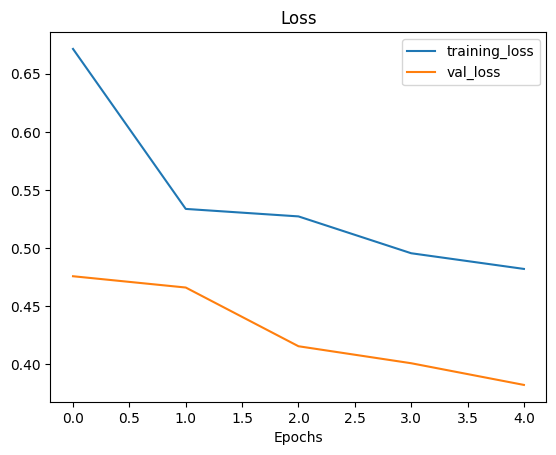

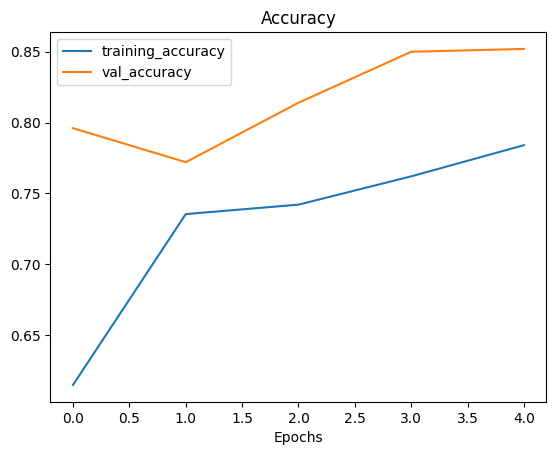

In [142]:
# Check out the TinyVGG model performance
plot_loss_curves(history_8)

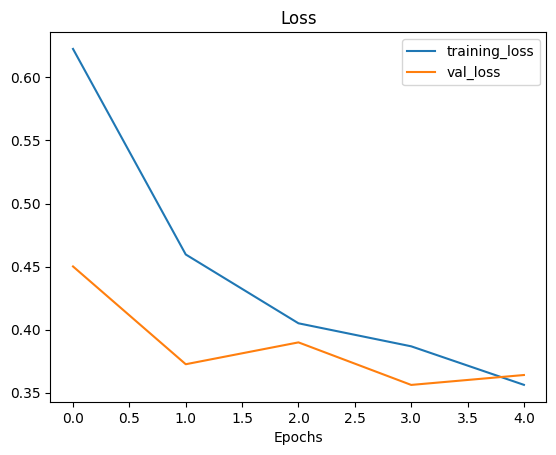

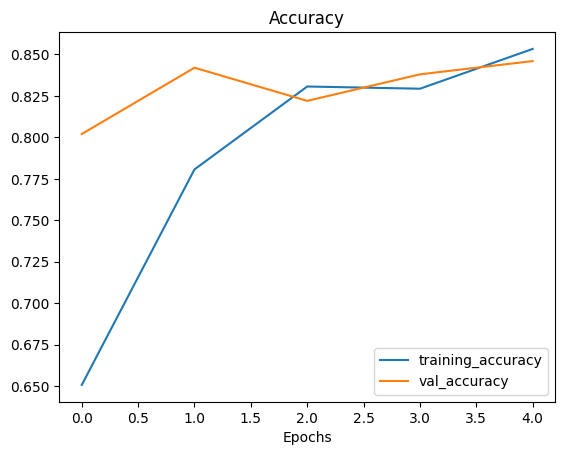

In [143]:
# How does this training curve look compared to the one above?
plot_loss_curves(history_1)

Our training curves are looking good, but our model's performance on the training and test sets didn't improve much compared to the previous model.

Taking another loook at the training curves, it looks like our model's performance might improve if we trained it a little longer (more epochs).

Perhaps that's something you like to try?

### Making a prediction with our trained model

In [144]:
# Classes we are working with.
print(class_names)

['pizza' 'steak']


--2025-02-13 15:57:07--  https://raw.githubusercontent.com/mrdbourke/tensorflow-deep-learning/main/images/03-steak.jpeg
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.110.133, 185.199.111.133, 185.199.108.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.110.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1978213 (1.9M) [image/jpeg]
Saving to: ‘03-steak.jpeg.1’

03-steak.jpeg.1     100%[===================>]   1.89M  --.-KB/s    in 0.01s   

2025-02-13 15:57:07 (132 MB/s) - ‘03-steak.jpeg.1’ saved [1978213/1978213]



(-0.5, 3023.5, 4031.5, -0.5)

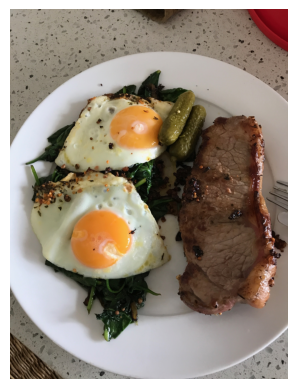

In [147]:
# Viewing our example image which will be passing for the predictions.
!wget https://raw.githubusercontent.com/mrdbourke/tensorflow-deep-learning/main/images/03-steak.jpeg

steak = mpimg.imread("03-steak.jpeg")
plt.imshow(steak)
plt.axis(False)

In [148]:
# Check the shape of our image
steak.shape

(4032, 3024, 3)

Since, our model takes in images of shapes `(224, 224, 3)`, we've got to reshape our custom image to use it with our model.

To do so, we can import and decode our image using `tf.io.read_file` (for readining files) and `tf.image` (for resizing our image and turning it into a tensor).

🔑 `Note:-` For the model to make predictions on unseen data, for example, our own custom images, the custom image has to be in the same shape as our model has been trained on. In more general terms, to make predictions on custom data it has to be in the same form that your model has been trained on.

In [151]:
# Create a function to import an image and resize it to be able to be used with our model.
def load_and_prep_image(filename, img_shape=224):
    """
    Reads an image from filename, turns it into a tensor.
    and reshapes it to (image_shape, image_shape, colour_channel).
    """
    # Read in target file (an image).
    img = tf.io.read_file(filename)

    # Decode the read file into a tensor & ensure 3 colour channels.
    # (our model is trained on images with 3 colour channels and sometimes images have 4 colour channels).
    img = tf.image.decode_image(img, channels=3)

    # Resize the images (to the same size our model was trained on).
    img = tf.image.resize(img, size=[img_shape, img_shape])

    # Rescale the image (get all values between 0 & 1)
    img = img / 255.

    return img

# Load in and preprocess our custom images.
steak = load_and_prep_image("03-steak.jpeg")
steak

<tf.Tensor: shape=(224, 224, 3), dtype=float32, numpy=
array([[[0.6377451 , 0.6220588 , 0.57892156],
        [0.6504902 , 0.63186276, 0.5897059 ],
        [0.63186276, 0.60833335, 0.5612745 ],
        ...,
        [0.52156866, 0.05098039, 0.09019608],
        [0.49509802, 0.04215686, 0.07058824],
        [0.52843136, 0.07745098, 0.10490196]],

       [[0.6617647 , 0.6460784 , 0.6107843 ],
        [0.6387255 , 0.6230392 , 0.57598037],
        [0.65588236, 0.63235295, 0.5852941 ],
        ...,
        [0.5352941 , 0.06862745, 0.09215686],
        [0.529902  , 0.05931373, 0.09460784],
        [0.5142157 , 0.05539216, 0.08676471]],

       [[0.6519608 , 0.6362745 , 0.5892157 ],
        [0.6392157 , 0.6137255 , 0.56764704],
        [0.65637255, 0.6269608 , 0.5828431 ],
        ...,
        [0.53137255, 0.06470589, 0.08039216],
        [0.527451  , 0.06862745, 0.1       ],
        [0.52254903, 0.05196078, 0.0872549 ]],

       ...,

       [[0.49313724, 0.42745098, 0.31029412],
        [0.05

In [152]:
# Make a prediction on our custom image (spoiler: this won't work)
model_8.predict(steak)

ValueError: Exception encountered when calling Sequential.call().

[1mInvalid input shape for input Tensor("data:0", shape=(32, 224, 3), dtype=float32). Expected shape (None, 224, 224, 3), but input has incompatible shape (32, 224, 3)[0m

Arguments received by Sequential.call():
  • inputs=tf.Tensor(shape=(32, 224, 3), dtype=float32)
  • training=False
  • mask=None

There's one more problem...

Although our image is in the same shape as the images our model has been trained on, we're still missing a dimension.

Remember how our model was trained in batches?

Well, the batch size becomes the first dimension.

So in reality, our model was trained on data in the shape of (batch_size, 224, 224, 3).

We can fix this by adding an extra to our custom image tensor using `tf.expand_dims`.

In [153]:
# Adding an extra axis.
print(f"Shape before new dimension: {steak.shape}")
steak = tf.expand_dims(steak, axis=0) # adding an extra dimension at axis 0.

print(f"Shape after new dimension: {steak.shape}")
steak

Shape before new dimension: (224, 224, 3)
Shape after new dimension: (1, 224, 224, 3)


<tf.Tensor: shape=(1, 224, 224, 3), dtype=float32, numpy=
array([[[[0.6377451 , 0.6220588 , 0.57892156],
         [0.6504902 , 0.63186276, 0.5897059 ],
         [0.63186276, 0.60833335, 0.5612745 ],
         ...,
         [0.52156866, 0.05098039, 0.09019608],
         [0.49509802, 0.04215686, 0.07058824],
         [0.52843136, 0.07745098, 0.10490196]],

        [[0.6617647 , 0.6460784 , 0.6107843 ],
         [0.6387255 , 0.6230392 , 0.57598037],
         [0.65588236, 0.63235295, 0.5852941 ],
         ...,
         [0.5352941 , 0.06862745, 0.09215686],
         [0.529902  , 0.05931373, 0.09460784],
         [0.5142157 , 0.05539216, 0.08676471]],

        [[0.6519608 , 0.6362745 , 0.5892157 ],
         [0.6392157 , 0.6137255 , 0.56764704],
         [0.65637255, 0.6269608 , 0.5828431 ],
         ...,
         [0.53137255, 0.06470589, 0.08039216],
         [0.527451  , 0.06862745, 0.1       ],
         [0.52254903, 0.05196078, 0.0872549 ]],

        ...,

        [[0.49313724, 0.42745098, 

In [154]:
# Make a prediction by passing a custom image tensor.
pred = model_8.predict(steak)
pred

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 200ms/step


array([[0.8334455]], dtype=float32)

Ahh, the predictions come out in `prediction probability` form. In other words, this means how likely the image is to be one class or another.

Since we're working with a binary classification problem, if the prediction probability is over 0.5, according to the model, the prediction is most likely to be the `postive class` (class 1).

And if the prediction probability is under 0.5, according to the model, the predicted class is most likely to be the `negative class` (class 0).

> 🔑 Note: The `0.5` cutoff can be adjusted to our liking. For example, we could set the limit to be 0.8 and over for the positive class and 0.2 for the negative class. However, doing this will almost always change your model's performance metrics so be sure to make sure they change in the right direction.

But saying positive and negative class doesn't make much sense when we're working with pizza 🍕 and steak 🥩...



So let's write a little function to convert predictions into their class names and then plot the target image.

In [155]:
# Remind ourselves of our class names
class_names

array(['pizza', 'steak'], dtype='<U5')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step


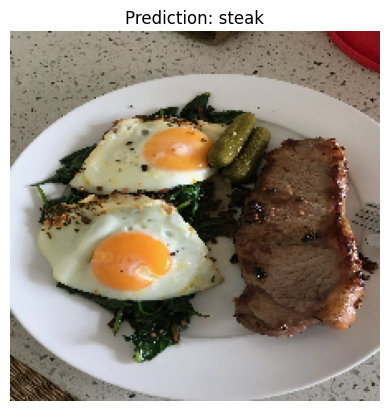

In [157]:
# We can index the predicted class by rounding the prediction probability
def pred_and_plot(model, filename, class_names):
    """
    Imports a image located at filename, makes a prediction on it with a trained model and plots the image with the predicted class as the title.
    """
    # Import the target image and preprocess it.
    img = load_and_prep_image(filename)

    # Make a prediction.
    pred = model.predict(tf.expand_dims(img, axis=0))

    # Get the predicted class.
    pred_class = class_names[int(tf.round(pred)[0][0])]

    # Plot the image and predicted class.
    plt.imshow(img)
    plt.title(f"Prediction: {pred_class}")
    plt.axis(False)

# Test our model on a custom image
pred_and_plot(model_8, "03-steak.jpeg", class_names)

## Multi-class Classification

How about we go through those steps again, except this time, we'll work with 10 different types of food.

* Become one with the data (visualize, visualize, visualize...)
* Preprocess the data (prepare it for a model)
* Create a model (start with a baseline)
* Fit the model
* Evaluate the model
* Adjust different parameters and improve model (try to beat your baseline)
* Repeat until satisfied

### 1. Import and become one with the data

In [158]:
import zipfile

# Download zip file of 10_food_classes images
# See how this data was created - https://github.com/mrdbourke/tensorflow-deep-learning/blob/main/extras/image_data_modification.ipynb
!wget https://storage.googleapis.com/ztm_tf_course/food_vision/10_food_classes_all_data.zip

# Unzip the downloaded file
zip_ref = zipfile.ZipFile("10_food_classes_all_data.zip", "r")
zip_ref.extractall()
zip_ref.close()

--2025-02-13 16:30:42--  https://storage.googleapis.com/ztm_tf_course/food_vision/10_food_classes_all_data.zip
Resolving storage.googleapis.com (storage.googleapis.com)... 142.251.16.207, 192.178.155.207, 142.251.163.207, ...
Connecting to storage.googleapis.com (storage.googleapis.com)|142.251.16.207|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 519183241 (495M) [application/zip]
Saving to: ‘10_food_classes_all_data.zip’

10_food_classes_all 100%[===================>] 495.13M  90.1MB/s    in 5.6s    

2025-02-13 16:30:48 (89.1 MB/s) - ‘10_food_classes_all_data.zip’ saved [519183241/519183241]



In [159]:
import os

# Walk through 10_food_classes directory and list number of files
for dirpath, dirnames, filenames in os.walk("10_food_classes_all_data"):
  print(f"There are {len(dirnames)} directories and {len(filenames)} images in '{dirpath}'.")

There are 2 directories and 0 images in '10_food_classes_all_data'.
There are 10 directories and 0 images in '10_food_classes_all_data/test'.
There are 0 directories and 250 images in '10_food_classes_all_data/test/steak'.
There are 0 directories and 250 images in '10_food_classes_all_data/test/pizza'.
There are 0 directories and 250 images in '10_food_classes_all_data/test/sushi'.
There are 0 directories and 250 images in '10_food_classes_all_data/test/hamburger'.
There are 0 directories and 250 images in '10_food_classes_all_data/test/chicken_wings'.
There are 0 directories and 250 images in '10_food_classes_all_data/test/grilled_salmon'.
There are 0 directories and 250 images in '10_food_classes_all_data/test/ice_cream'.
There are 0 directories and 250 images in '10_food_classes_all_data/test/fried_rice'.
There are 0 directories and 250 images in '10_food_classes_all_data/test/chicken_curry'.
There are 0 directories and 250 images in '10_food_classes_all_data/test/ramen'.
There are 

In [160]:
train_dir = "10_food_classes_all_data/train/"
test_dir = "10_food_classes_all_data/test/"

In [161]:
# Get the class names for our multi-class dataset
import pathlib
import numpy as np
data_dir = pathlib.Path(train_dir)
class_names = np.array(sorted([item.name for item in data_dir.glob('*')]))
print(class_names)

['chicken_curry' 'chicken_wings' 'fried_rice' 'grilled_salmon' 'hamburger'
 'ice_cream' 'pizza' 'ramen' 'steak' 'sushi']


Image shape: (512, 512, 3)


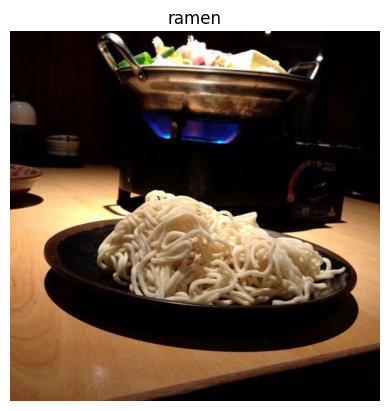

In [162]:
# View a random image from the training dataset
import random
img = view_random_image(target_dir=train_dir,
                        target_class=random.choice(class_names)) # get a random class name

### 2. Preprocess the data (prepare it for a model)

In [163]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Rescale the data and create data generator instances
train_datagen = ImageDataGenerator(rescale=1/255.)
test_datagen = ImageDataGenerator(rescale=1/255.)

# Load data in from directories and turn it into batches
train_data = train_datagen.flow_from_directory(train_dir,
                                               target_size=(224, 224),
                                               batch_size=32,
                                               class_mode='categorical') # changed to categorical

test_data = train_datagen.flow_from_directory(test_dir,
                                              target_size=(224, 224),
                                              batch_size=32,
                                              class_mode='categorical')

Found 7500 images belonging to 10 classes.
Found 2500 images belonging to 10 classes.


As with binary classifcation, we've creator image generators. The main change this time is that we've changed the `class_mode parameter` to `'categorical'` because we're dealing with `10 classes` of food images.

Everything else like rescaling the images, creating the `batch size` and `target image size` stay the same.

> 🤔 `Question:-` Why is the image size 224x224 ? This could actually be any size we wanted, however, 224x224 is a very common size for preprocessing images to. Depending on problem we might want to use larger or smaller images.

### 3. Create a model (start with a baseline).

We can use the same model (TinyVGG) we used for the binary classification problem for our multi-class classification problem with a couple of small tweaks.

Namely:

* Changing the `output layer` to use have `10 ouput neurons` (the same number as the number of `classes` we have).

* Changing the `output layer` to use `'softmax'` activation instead of `'sigmoid'` activation.

* Changing the `loss function` to be `'categorical_crossentropy'` instead of `'binary_crossentropy'`.

In [165]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPool2D, Flatten, Dense

# Create our model (a clone of model_8, except to be multi-class)
model_9 = Sequential([
  Conv2D(10, 3, activation='relu', input_shape=(224, 224, 3)),
  Conv2D(10, 3, activation='relu'),
  MaxPool2D(),
  Conv2D(10, 3, activation='relu'),
  Conv2D(10, 3, activation='relu'),
  MaxPool2D(),
  Flatten(),
  Dense(10, activation='softmax') # changed to have 10 neurons (same as number of classes) and 'softmax' activation
])

# Compile the model
model_9.compile(loss="categorical_crossentropy", # changed to categorical_crossentropy
                optimizer=tf.keras.optimizers.Adam(),
                metrics=["accuracy"])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


### 4. Fit a model

In [ ]:
# Fit the model
history_9 = model_9.fit(train_data, # now 10 different classes
                        epochs=5,
                        steps_per_epoch=len(train_data),
                        validation_data=test_data,
                        validation_steps=len(test_data))

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 528s 2s/step - accuracy: 0.1225 - loss: 2.3945 - val_accuracy: 0.2640 - val_loss: 2.0526
Epoch 2/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 563s 2s/step - accuracy: 0.2900 - loss: 2.0128 - val_accuracy: 0.3172 - val_loss: 1.9266
Epoch 3/5
203/235 ━━━━━━━━━━━━━━━━━━━━ 1:03 2s/step - accuracy: 0.3609 - loss: 1.8576


Model takes longer than when working with only two classes of images It's because we're now dealing with more images than we were before. We've got `10 classes` with `750 training images` and `250 validation images` each totalling `10,000 images`. Where as when we had `two classes`, we had `1500 training images` and `500 validation images`, totalling `2000`.

### 5. Evaluate the model

In [ ]:
# We've just trained a model on 10 different classes of food images, let's see how it went.


# Evaluate on the test data
model_9.evaluate(test_data)

In [ ]:
# Check out the model's loss curves on the 10 classes of data (note: this function comes from above in the notebook)
plot_loss_curves(history_9)

That's quite the gap between the training and validation loss curves.

What does this tell us?

It seems our model is overfitting the training set quite badly. In other words, it's getting great results on the training data but fails to generalize well to unseen data and performs poorly on the test data.

### 6. Adjust the model parameters

Due to its performance on the training data, it's clear our model is learning something. However, performing well on the training data is like going well in the classroom but failing to use your skills in real life.

Ideally, we'd like our model to perform as well on the test data as it does on the training data.

So our next steps will be to try and prevent our model overfitting. A couple of ways to prevent overfitting include:

* `Get more data` - Having more data gives the model more opportunities to learn patterns, patterns which may be more generalizable to new examples.

* `Simplify model` - If the current model is already overfitting the training data, it may be too complicated of a model. This means it's learning the patterns of the data too well and isn't able to generalize well to unseen data.
One way to simplify a model is to reduce the number of layers it uses or to reduce the number of hidden units in each layer.

* `Use data augmentation` - Data augmentation manipulates the training data in a way so that's harder for the model to learn as it artificially adds more variety to the data. If a model is able to learn patterns in augmented data, the model may be able to generalize better to unseen data.

* `Use transfer learning` - Transfer learning involves leverages the patterns (also called pretrained weights) one model has learned to use as the foundation for your own task. In our case, we could use one computer vision model pretrained on a large variety of images and then tweak it slightly to be more specialized for food images.

> 🔑 `Note:-` Preventing overfitting is also referred to as regularization.

How about we simplify our model first?

To do so, we'll remove two of the convolutional layers, taking the total number of convolutional layers from four to two.

In [ ]:
# Try a simplified model (removed two layers)
model_10 = Sequential([
  Conv2D(10, 3, activation='relu', input_shape=(224, 224, 3)),
  MaxPool2D(),
  Conv2D(10, 3, activation='relu'),
  MaxPool2D(),
  Flatten(),
  Dense(10, activation='softmax')
])

model_10.compile(loss='categorical_crossentropy',
                 optimizer=tf.keras.optimizers.Adam(),
                 metrics=['accuracy'])

history_10 = model_10.fit(train_data,
                          epochs=5,
                          steps_per_epoch=len(train_data),
                          validation_data=test_data,
                          validation_steps=len(test_data))

In [ ]:
# Check out the loss curves of model_10
plot_loss_curves(history_10)

Even with a simplifed model, it looks like our model is still dramatically overfitting the training data.

What else could we try?

How about `data augmentation` ?

 * Data augmentation makes it harder for the model to learn on the training data and in turn, hopefully making the patterns it learns more generalizable to unseen data.

* To create augmented data, we'll recreate a new `ImageDataGenerator` instance, this time adding some parameters such as `rotation_range` and `horizontal_flip` to manipulate our images.



In [ ]:

# Create augmented data generator instance
train_datagen_augmented = ImageDataGenerator(rescale=1/255.,
                                             rotation_range=20, # note: this is an int not a float
                                             width_shift_range=0.2,
                                             height_shift_range=0.2,
                                             zoom_range=0.2,
                                             horizontal_flip=True)

train_data_augmented = train_datagen_augmented.flow_from_directory(train_dir,
                                                                  target_size=(224, 224),
                                                                  batch_size=32,
                                                                  class_mode='categorical')

Now we've got augmented data, let's see how it works with the same model as before (model_10).

Rather than rewrite the model from scratch, we can clone it using a handy function in TensorFlow called clone_model which can take an existing model and rebuild it in the same format.

The cloned version will not include any of the weights (patterns) the original model has learned. So when we train it, it'll be like training a model from scratch.



> 🔑 `Note:-` One of the key practices in deep learning and machine learning in general is to be a serial experimenter. That's what we're doing here. Trying something, seeing if it works, then trying something else. A good experiment setup also keeps track of the things you change, for example, that's why we're using the same model as before but with different data. The model stays the same but the data changes, this will let us know if augmented training data has any influence over performance.

In [ ]:
# Clone the model (use the same architecture)
model_11 = tf.keras.models.clone_model(model_10)

# Compile the cloned model (same setup as used for model_10)
model_11.compile(loss="categorical_crossentropy",
              optimizer=tf.keras.optimizers.Adam(),
              metrics=["accuracy"])

# Fit the model
history_11 = model_11.fit(train_data_augmented, # use augmented data
                          epochs=5,
                          steps_per_epoch=len(train_data_augmented),
                          validation_data=test_data,
                          validation_steps=len(test_data))

We can see it each epoch takes longer than the previous model. This is because our data is being augmented on the fly on the CPU as it gets loaded onto the GPU, in turn, increasing the amount of time between each epoch.

> **Note:-** One way to improve this time taken is to use augmentation layers directly as part of the model. For example,
* with `tf.keras.layers.RandomFlip`. You can also speed up data loading with the newer.
* `tf.keras.utils.image_dataset_from_directory` image loading API (we cover this later in the course).

In [ ]:
# Check out our model's performance with augmented data
plot_loss_curves(history_11)

That's looking much better, the loss curves are much closer to eachother. Although our model didn't perform as well on the augmented training set, it performed much better on the validation dataset.

It even looks like if we kept it training for longer (more epochs) the evaluation metrics might continue to improve.


### 7. Repeat until satisfied

We could keep going here. Restructuring our model's architecture, adding more layers, trying it out, adjusting the learning rate, trying it out, trying different methods of data augmentation, training for longer. But as you could image, this could take a fairly long time.

Good thing there's still one trick we haven't tried yet and that's `transfer learning`.

However, we'll save that for the next notebook where you'll see how rather than design our own models from scratch we leverage the patterns another model has learned for our own task.

In the meantime, let's make a prediction with our trained multi-class model.

#### Making a prediction with our trained model

In [ ]:
# What classes has our model been trained on?
class_names


### Saving and loading our model

In [ ]:
# Save a model
model_11.save("saved_trained_model")

In [ ]:
# Load in a model and evaluate it
loaded_model_11 = tf.keras.models.load_model("saved_trained_model")
loaded_model_11.evaluate(test_data)

In [ ]:
# Compare our unsaved model's results (same as above)
model_11.evaluate(test_data)